# 06 · Global heat questions, African heat laboratory

**Time:** 40 minutes · **Audience:** undergraduate / introductory graduate GIS and Earth science.

**By the end:** Map temperature exceedance while distinguishing air temperature, thermal stress, exposure, and vulnerability.

[Run in JupyterLite](https://jltobias.github.io/JupyterLite-zarr-sql-views/lite/lab/index.html?path=06_heat_stress.ipynb) · [Earth lab](https://jltobias.github.io/JupyterLite-zarr-sql-views/lab/) · [Sources and licenses](https://jltobias.github.io/JupyterLite-zarr-sql-views/book/credits.html)

Run cells from top to bottom with **Shift+Enter**. The first kernel start downloads Python WebAssembly packages.
The bundled exercises need no data-service account. Save a copy with **File → Save and Export Notebook As** before clearing browser storage.

![Four-stage workflow: STAC discovery, Zarr reading, SQL selection, linked views](assets/pipeline.svg)

In [1]:
from course import *
import numpy as np
import matplotlib.pyplot as plt
print('Ready: Python + NumPy + local teaching data')

Ready: Python + NumPy + local teaching data


## 1. State the evidence type

This cube is an **analytic synthetic field**, spanning an Africa-centred rectangle including ocean cells.
The twelve labels are fictional months in 2000, not a reanalysis. We use it to learn aggregation and threshold sensitivity.
Air temperature alone cannot calculate wet-bulb temperature or UTCI. Humidity, wind, radiation, and context matter.
For real global comparison, use the C3S Atlas or a documented thermal-stress product with its own definitions.

Analytic seasonal temperature field. Not ERA5, UTCI, wet-bulb temperature, or an observed heat event.


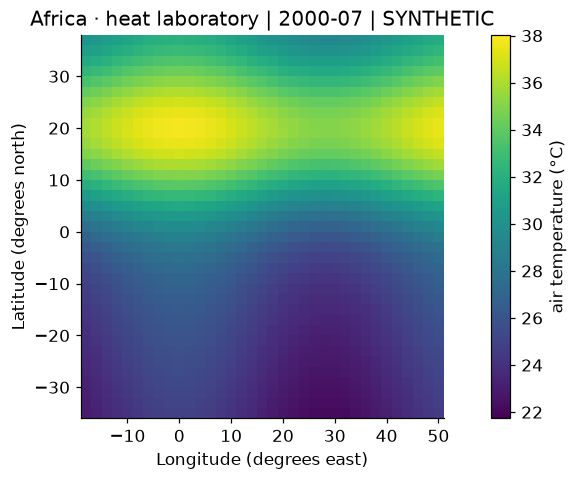

In [2]:
meta,heat=load_cube('heat')
print(meta['description'])
map_slice(meta,heat,6);plt.show()

## 2. Compare a chosen threshold across latitude bands

The 32°C threshold here is a teaching parameter, not a health recommendation. A count of monthly synthetic means above it
is not a count of hot days. Label the temporal aggregation honestly.

2000-01 232
2000-02 278
2000-03 341
2000-04 396
2000-05 448
2000-06 465
2000-07 448
2000-08 396
2000-09 341
2000-10 278
2000-11 232
2000-12 209


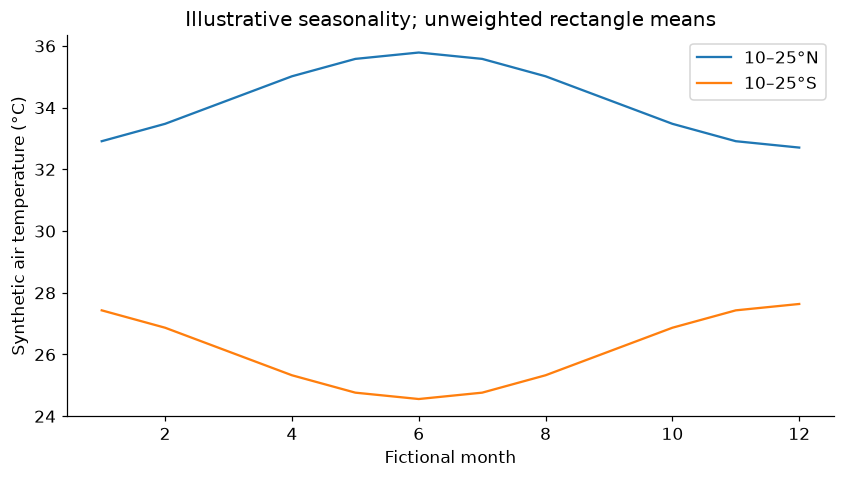

In [3]:
threshold=32.0
con=sql_connection(meta,heat)
for row in con.execute('SELECT t, COUNT(*) FROM cells WHERE value > ? GROUP BY t ORDER BY t',(threshold,)):
    print(meta['times'][row[0]],row[1])
fig,ax=plt.subplots()
for low,high,label in [(10,25,'10–25°N'),(-25,-10,'10–25°S')]:
    keep=(np.asarray(meta['lat'])>=low)&(np.asarray(meta['lat'])<=high)
    ax.plot(range(1,13),heat[:,keep,:].mean(axis=(1,2)),label=label)
ax.set(xlabel='Fictional month',ylabel='Synthetic air temperature (°C)',title='Illustrative seasonality; unweighted rectangle means');ax.legend();plt.show()

## 3. Test weighting

On a regular latitude-longitude grid, cell areas vary with latitude. Cosine-latitude weighting approximates an area mean.
It does not make a land-only mean or a population-exposure mean. Those need masks and an appropriately aligned population dataset.

In [4]:
weights=np.broadcast_to(np.cos(np.deg2rad(meta['lat']))[:,None],heat.shape[1:])
weighted=np.array([np.average(v,weights=weights) for v in heat])
print('Unweighted:',np.round(heat.mean(axis=(1,2)),2))
print('Area-weighted approximation:',np.round(weighted,2))

Unweighted: [29.1  29.13 29.17 29.21 29.24 29.25 29.24 29.21 29.17 29.13 29.1  29.08]
Area-weighted approximation: [29.12 29.15 29.18 29.22 29.24 29.25 29.24 29.22 29.18 29.15 29.12 29.11]


In [5]:
lab('heat','cube')

## 4. Design a global comparison

Compare Lagos, Delhi, and São Paulo using a common real dataset, time interval, UTCI definition, and spatial support in a follow-on project.
Explain the difference between hazard (thermal conditions), exposure (people and activities), and vulnerability (ability to cope).
Do not rank cities from the synthetic Africa-only grid.

## Try it yourself

Try thresholds of 30, 32, and 34°C. Then explain what additional inputs are needed to discuss worker heat stress.

## Check your reasoning

Threshold choice changes the result. Temperature-only monthly fields cannot identify daily dangerous conditions or personal health risk.

## Evidence journal

Write four sentences: **what I observed; how I calculated it; what this cannot establish; what evidence I need next**.
For any figure you reuse, retain its units, date or scenario, data origin, transformations, and attribution.

## Sources and credit

- [IPCC AR6 WGII, Chapter 9: Africa](https://www.ipcc.ch/report/ar6/wg2/chapter/chapter-9/). Linked context, not redistributed data.
- [Copernicus: data and methods, including UTCI](https://climate.copernicus.eu/GCH2025-about-data-and-methods)

Teaching adaptation of [dzole0311/zarr-sql-views](https://github.com/dzole0311/zarr-sql-views), ISC.
Original teaching code and prose: JupyterLite-zarr-sql-views contributors, ISC. Data keep their separate licenses.